## Import libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Read the input file

In [3]:
df = pd.read_csv('C:\\Rekha\\InputFiles\\Student.csv')

## Explore the data

In [3]:
df.head(3)

,gender,group,math_score,reading_score,writing_score
0,female,group B,72.0,72.0,74.0
1,female,group C,69.0,90.0,88.0
2,female,group B,90.0,95.0,93.0


In [7]:
df.tail()

,gender,group,math_score,reading_score,writing_score
1003,female,group D,77.0,86.0,86.0
1004,male,group C,62.0,55.0,55.0
1005,NaN,group C,59.0,NaN,NaN
1006,female,NaN,68.0,78.0,77.0
1007,female,group D,NaN,86.0,86.0


In [4]:
df.shape

(1008, 5)

In [5]:
df.describe()

,math_score,reading_score,writing_score
count,1006.000000,1007.000000,1007.000000
mean,66.079523,69.193644,68.078451
std,15.126190,14.587749,15.180518
min,0.000000,17.000000,10.000000
25%,57.000000,59.000000,57.500000
50%,66.000000,70.000000,69.000000
75%,77.000000,79.000000,79.000000
max,100.000000,100.000000,100.000000


In [6]:
df.size

5040

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   gender         1006 non-null   object 
 1   group          1006 non-null   object 
 2   math_score     1006 non-null   float64
 3   reading_score  1007 non-null   float64
 4   writing_score  1007 non-null   float64
dtypes: float64(3), object(2)
memory usage: 39.5+ KB


## Data cleaning and preparation
* Check for null values
* Drop the null values or apply fillna method
* Replace values in columns

In [42]:
df.isna().sum()

gender           2
group            2
math_score       2
reading_score    1
writing_score    1
dtype: int64

In [8]:
cond=df.duplicated()
cond

0       False
1       False
2       False
3       False
4       False
        ...  
1003     True
1004     True
1005    False
1006    False
1007    False
Length: 1008, dtype: bool

In [9]:
df[cond]

,gender,group,math_score,reading_score,writing_score
613,female,group C,65.0,77.0,74.0
962,female,group E,100.0,100.0,100.0
1000,male,group C,62.0,55.0,55.0
1003,female,group D,77.0,86.0,86.0
1004,male,group C,62.0,55.0,55.0


In [10]:
df.drop_duplicates()

,gender,group,math_score,reading_score,writing_score
0,female,group B,72.0,72.0,74.0
1,female,group C,69.0,90.0,88.0
2,female,group B,90.0,95.0,93.0
3,male,group A,47.0,57.0,44.0
4,male,group C,76.0,78.0,75.0
...,...,...,...,...,...
1001,NaN,group C,59.0,71.0,65.0
1002,female,NaN,NaN,78.0,77.0
1005,NaN,group C,59.0,NaN,NaN
1006,female,NaN,68.0,78.0,77.0


In [11]:
df.isna().sum()

gender           2
group            2
math_score       2
reading_score    1
writing_score    1
dtype: int64

In [12]:
df.math_score.isna()

0       False
1       False
2       False
3       False
4       False
        ...  
1003    False
1004    False
1005    False
1006    False
1007     True
Name: math_score, Length: 1008, dtype: bool

In [56]:
df[df.math_score.isna()]

,gender,group,math_score,reading_score,writing_score
1002,female,NaN,NaN,78.0,77.0
1007,female,group D,NaN,86.0,86.0


In [15]:
df.dropna(axis=0)

,gender,group,math_score,reading_score,writing_score
0,female,group B,72.0,72.0,74.0
1,female,group C,69.0,90.0,88.0
2,female,group B,90.0,95.0,93.0
3,male,group A,47.0,57.0,44.0
4,male,group C,76.0,78.0,75.0
...,...,...,...,...,...
998,female,group D,68.0,78.0,77.0
999,female,group D,77.0,86.0,86.0
1000,male,group C,62.0,55.0,55.0
1003,female,group D,77.0,86.0,86.0


In [16]:
df.nunique()

gender            2
group             5
math_score       81
reading_score    72
writing_score    77
dtype: int64

In [17]:
df.group.value_counts()

group C    323
group D    264
group B    190
group E    140
group A     89
Name: group, dtype: int64

## Analysing the data

In [16]:
df.groupby(by=["gender"]).count()

,group,math_score,reading_score,writing_score
gender,,,,
female,520,520,522,522
male,484,484,484,484


In [36]:
df1=df.groupby(by="group").agg('count')

In [37]:
df1= df1.reset_index()

<AxesSubplot:xlabel='group', ylabel='math_score'>

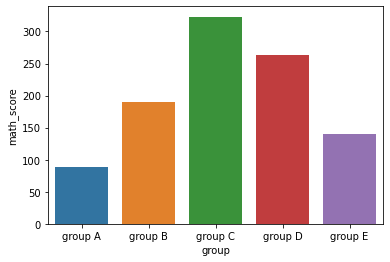

In [38]:
sns.barplot(x="group",y="math_score",data=df1)

In [ ]:
#### Find mean

In [31]:
df1=df.groupby(by="group").agg('mean')

In [34]:
df1= df1.reset_index().sort_values(by="math_score",ascending=False)

<AxesSubplot:xlabel='group', ylabel='math_score'>

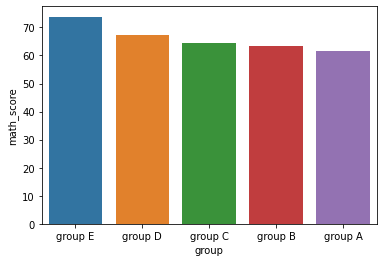

In [35]:
sns.barplot(x="group",y="math_score",data=df1)

array([[<AxesSubplot:title={'center':'math_score'}>,
        <AxesSubplot:title={'center':'reading_score'}>],
       [<AxesSubplot:title={'center':'writing_score'}>, <AxesSubplot:>]],
      dtype=object)

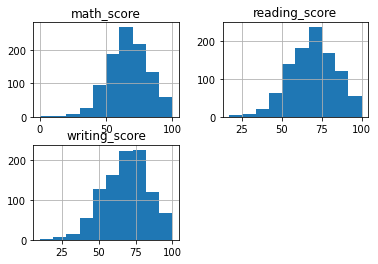

In [15]:
df.hist()   # histogram ploted for all numerical data

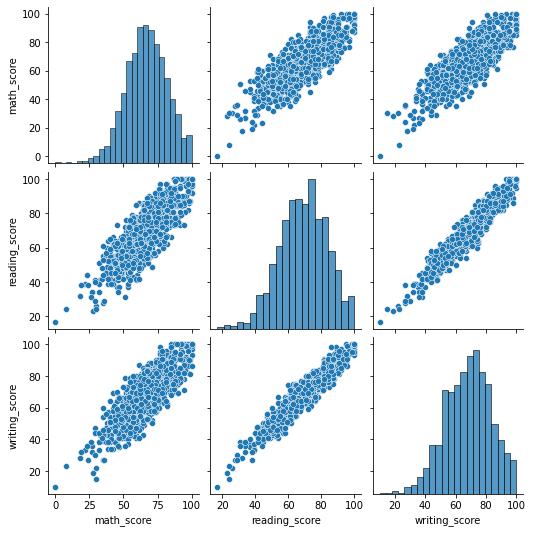

In [18]:
sns.pairplot(df)

In [9]:
corr_matrix = df.corr()

<AxesSubplot:>

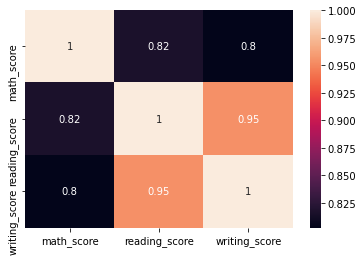

In [10]:
sns.heatmap(corr_matrix,xticklabels=corr_matrix.columns,yticklabels=corr_matrix.columns,annot=True)

<AxesSubplot:xlabel='math_score', ylabel='Density'>

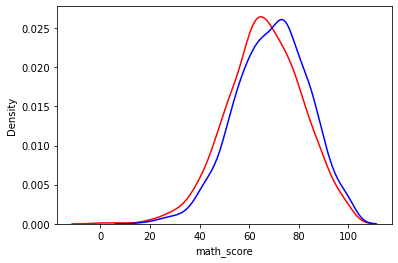

In [11]:
math_score = df["math_score"]
reading_score = df["reading_score"]
sns.kdeplot(math_score,color="r")
sns.kdeplot(reading_score,color="b")

<AxesSubplot:xlabel='group', ylabel='math_score'>

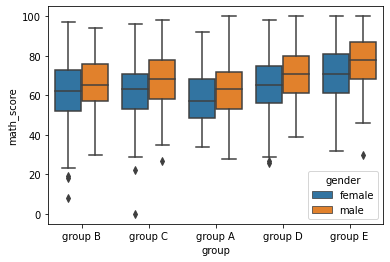

In [59]:
sns.boxplot(x="group",y="math_score",data=df,hue="gender")


In [51]:
cond = df["math_score"] < 20
df[cond].gender.count()

4

In [45]:
df["math_score"].describe()

count    1000.00000
mean       66.08900
std        15.16308
min         0.00000
25%        57.00000
50%        66.00000
75%        77.00000
max       100.00000
Name: math_score, dtype: float64

<AxesSubplot:xlabel='group', ylabel='math_score'>

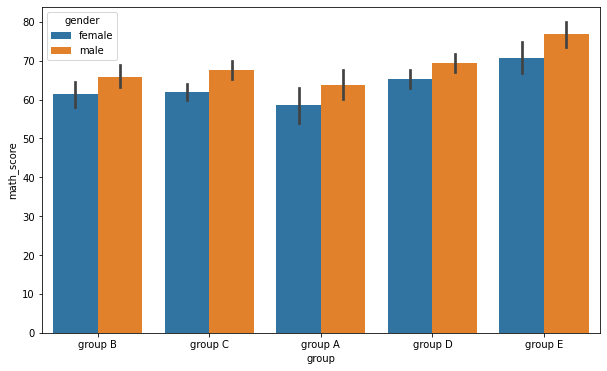

In [68]:
plt.figure(figsize=(10,6))
sns.barplot(x="group",y="math_score",data=df,hue="gender")

<AxesSubplot:xlabel='math_score', ylabel='Count'>

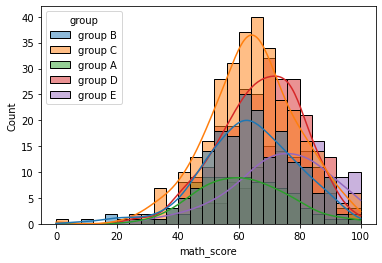

In [105]:
sns.histplot(x="math_score",data=df,kde=True,hue="group")